In [1]:
import sys
print("Python:", sys.version)


Python: 3.11.13 (main, Jun  4 2025, 08:57:29) [GCC 11.4.0]


In [2]:
import glob
import os
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import rcParams

seed = 9001
np.random.seed(seed)

### Create function to load individual patient data into one big dataframe

In [3]:
regex = re.compile(r'\d+')

DATA_DIR = "/kaggle/input/training-sepsis-dataset"  # Path to the data

def load_single_file(file_path):
    df = pd.read_csv(file_path, sep='|')
    df['hour'] = np.arange(len(df))  # hour within each patient stay

    # Extract the patient number from the file name, e.g. p00001.psv -> 1.
    patient_nums = regex.findall(os.path.basename(file_path))
    df['patient'] = int(patient_nums[0]) if patient_nums else np.nan
    return df

def get_data_files():
    return sorted(glob.glob(os.path.join(DATA_DIR, '**', '*.psv'), recursive=True))

def clean_data(data):
    data = data.reset_index(drop=True)
    return data

def load_data():
    df_list = []
    files = get_data_files()

    for i, file in enumerate(files):
        patient_df = load_single_file(file)
        patient_df['id'] = i   # Internal sequential patient ID starting from 0.
        df_list.append(patient_df)

    df = pd.concat(df_list, ignore_index=True)
    df = clean_data(df)

    # Sort each patient's records in temporal order.
    df = df.sort_values(['id', 'hour']).reset_index(drop=True)

    df = df.drop(columns=['patient'], errors='ignore')

    return df

In [4]:
# aggregate the individual patient data into one big data frame
df = load_data()
print(df.shape)
print(df[['id', 'hour']].head(10))
print(df[['id', 'hour']].tail(10))
print(df.sort_values(['id', 'hour']).equals(df))

(1552210, 43)
   id  hour
0   0     0
1   0     1
2   0     2
3   0     3
4   0     4
5   0     5
6   0     6
7   0     7
8   0     8
9   0     9
            id  hour
1552200  40335    25
1552201  40335    26
1552202  40335    27
1552203  40335    28
1552204  40335    29
1552205  40335    30
1552206  40335    31
1552207  40335    32
1552208  40335    33
1552209  40335    34
True


In [5]:
sepsis_start = (
    df[df["SepsisLabel"] == 1]
    .groupby("id")["hour"]
    .min()
    .reset_index(name="sepsis_hour")
)

early_ids = sepsis_start[sepsis_start["sepsis_hour"] < 10]["id"]

pid = early_ids.iloc[0]
patient_df = df[df["id"] == pid].copy()
patient_df = patient_df[patient_df["hour"] <= 24]


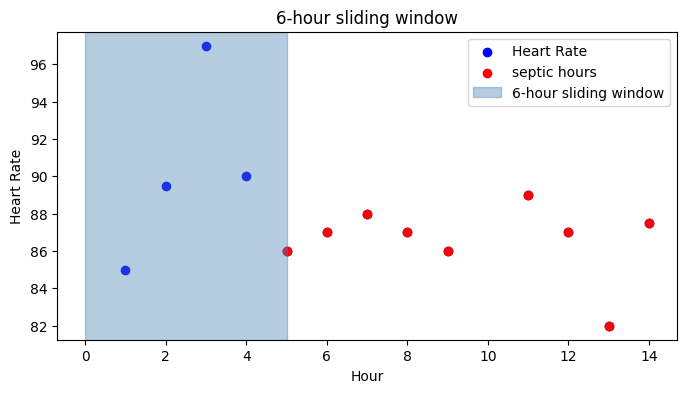

In [6]:
hours = patient_df["hour"]
hr = patient_df["HR"]
sepsis = patient_df["SepsisLabel"]

plt.figure(figsize=(8,4))

plt.scatter(hours, hr, color="blue", label="Heart Rate")
plt.scatter(hours[sepsis==1], hr[sepsis==1], color="red", label="septic hours")

plt.axvspan(0, 5, color="steelblue", alpha=0.4, label="6-hour sliding window")

plt.xlabel("Hour")
plt.ylabel("Heart Rate")
plt.title("6-hour sliding window")
plt.legend()
plt.show()


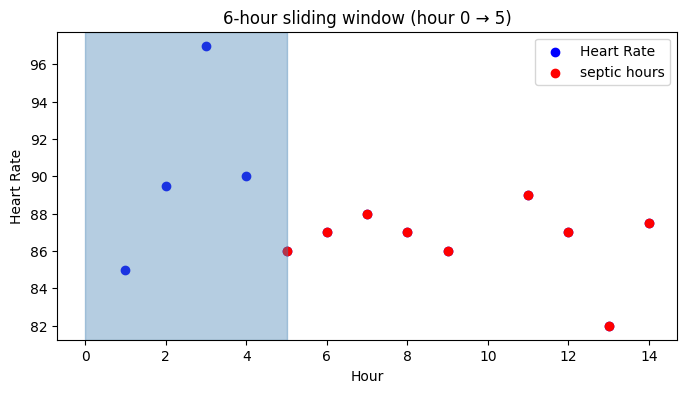

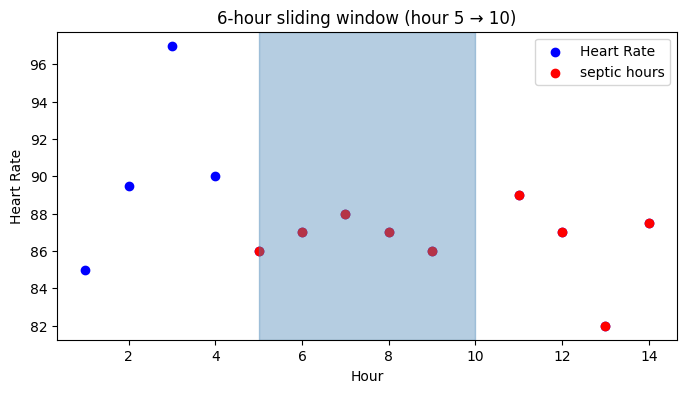

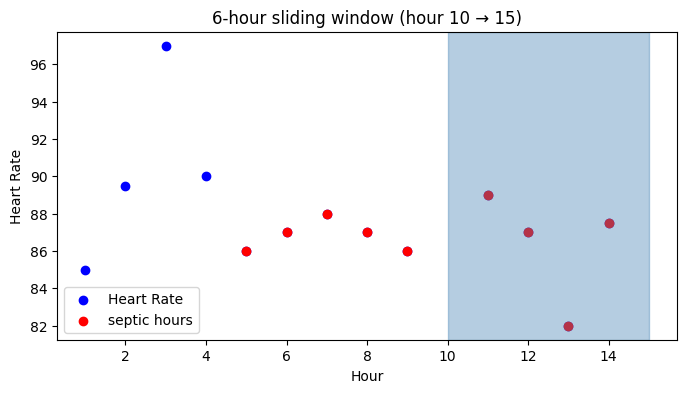

In [7]:
for start in [0, 5, 10]:
    plt.figure(figsize=(8,4))

    plt.scatter(hours, hr, color="blue", label="Heart Rate")
    plt.scatter(hours[sepsis==1], hr[sepsis==1], color="red", label="septic hours")

    plt.axvspan(start, start+5, color="steelblue", alpha=0.4)

    plt.title(f"6-hour sliding window (hour {start} → {start+5})")
    plt.xlabel("Hour")
    plt.ylabel("Heart Rate")
    plt.legend()
    plt.show()


# Data Exploration

In [8]:
df.columns # name of columns

Index(['HR', 'O2Sat', 'Temp', 'SBP', 'MAP', 'DBP', 'Resp', 'EtCO2',
       'BaseExcess', 'HCO3', 'FiO2', 'pH', 'PaCO2', 'SaO2', 'AST', 'BUN',
       'Alkalinephos', 'Calcium', 'Chloride', 'Creatinine', 'Bilirubin_direct',
       'Glucose', 'Lactate', 'Magnesium', 'Phosphate', 'Potassium',
       'Bilirubin_total', 'TroponinI', 'Hct', 'Hgb', 'PTT', 'WBC',
       'Fibrinogen', 'Platelets', 'Age', 'Gender', 'Unit1', 'Unit2',
       'HospAdmTime', 'ICULOS', 'SepsisLabel', 'hour', 'id'],
      dtype='object')

In [9]:
df.shape # dataset size: 1,552,210 rows x 43 columns

(1552210, 43)

In [10]:
df['SepsisLabel'].value_counts() # this is per event notes/records. NOT per patients

SepsisLabel
0    1524294
1      27916
Name: count, dtype: int64

### Distribution of sepsis labels vs total number of events

In [11]:
distribution = (df['SepsisLabel'].value_counts()[1] / sum(df['SepsisLabel'].value_counts()))
print('Distribution of sepsis events: ', distribution*100, '%')

Distribution of sepsis events:  1.798467990800214 %


### Plot the event-wise imbalance

Text(0.5, 1.0, 'Sepsis Label Distribution Event-wise')

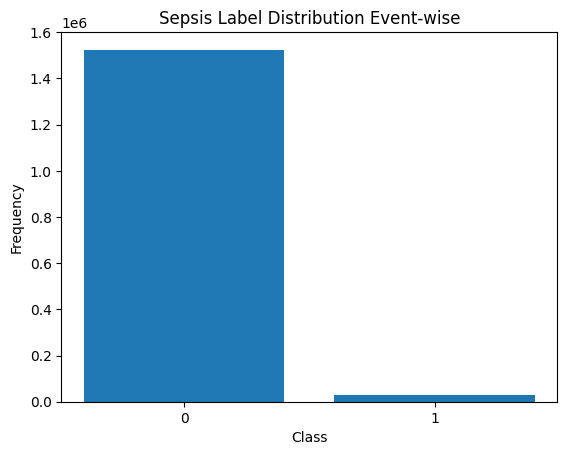

In [12]:
plt.bar(df['SepsisLabel'].value_counts().index, # x-values
        df['SepsisLabel'].value_counts()) # y-values
plt.xticks([0,1])
plt.xlabel('Class')
plt.ylabel('Frequency')
plt.title('Sepsis Label Distribution Event-wise')

### Distribution of sepsis patient-wise

In [13]:
grp_sepsis = df.groupby(['id'])['SepsisLabel'].sum() # sum sepsis labels grouped by 'id'. patients with sepsis have sum > 0

len(grp_sepsis[grp_sepsis > 0]) # total number of patients with sepsis

2932

In [14]:
sepsis_distr = len(grp_sepsis[grp_sepsis > 0]) / len(df['id'].unique())
print('Distribution of sepsis patients: ', sepsis_distr*100, '%')

Distribution of sepsis patients:  7.268940896469656 %


### Percentage of missing data per each variable

In [15]:
missing = (df.isnull().sum() / df.shape[0]) * 100
missing_sorted = missing.sort_values() # sorted percentage of missing data variables
missing_sorted

SepsisLabel          0.000000
ICULOS               0.000000
id                   0.000000
hour                 0.000000
Age                  0.000000
Gender               0.000000
HospAdmTime          0.000515
HR                   9.882619
MAP                 12.451279
O2Sat               13.061119
SBP                 14.576958
Resp                15.354559
DBP                 31.345887
Unit2               39.425078
Unit1               39.425078
Temp                66.162697
Glucose             82.894325
Potassium           90.689082
Hct                 91.145979
FiO2                91.665754
Hgb                 92.617558
pH                  93.069688
BUN                 93.134434
WBC                 93.593199
Magnesium           93.689578
Creatinine          93.904433
Platelets           94.059502
Calcium             94.116067
PaCO2               94.440121
BaseExcess          94.579020
Chloride            95.460279
HCO3                95.810618
Phosphate           95.986303
EtCO2     

In [16]:
# Keep a broad set of raw columns following the challenge feature set.
RAW_KEEP_COLS = [
    'HR', 'O2Sat', 'Temp', 'SBP', 'MAP', 'DBP', 'Resp', 'EtCO2',
    'BaseExcess', 'HCO3', 'FiO2', 'pH', 'PaCO2', 'SaO2',
    'AST', 'BUN', 'Alkalinephos', 'Calcium', 'Chloride', 'Creatinine',
    'Bilirubin_direct', 'Glucose', 'Lactate', 'Magnesium', 'Phosphate',
    'Potassium', 'Bilirubin_total', 'TroponinI', 'Hct', 'Hgb', 'PTT',
    'WBC', 'Fibrinogen', 'Platelets', 'Age', 'Gender',
    'HospAdmTime', 'ICULOS'
]

BASE_COLS = ['id', 'hour', 'SepsisLabel']

selected_cols = [col for col in BASE_COLS + RAW_KEEP_COLS if col in df.columns]
selected_cols

['id',
 'hour',
 'SepsisLabel',
 'HR',
 'O2Sat',
 'Temp',
 'SBP',
 'MAP',
 'DBP',
 'Resp',
 'EtCO2',
 'BaseExcess',
 'HCO3',
 'FiO2',
 'pH',
 'PaCO2',
 'SaO2',
 'AST',
 'BUN',
 'Alkalinephos',
 'Calcium',
 'Chloride',
 'Creatinine',
 'Bilirubin_direct',
 'Glucose',
 'Lactate',
 'Magnesium',
 'Phosphate',
 'Potassium',
 'Bilirubin_total',
 'TroponinI',
 'Hct',
 'Hgb',
 'PTT',
 'WBC',
 'Fibrinogen',
 'Platelets',
 'Age',
 'Gender',
 'HospAdmTime',
 'ICULOS']

### Exclude Unit1, Unit2, variables because these are just identifiers

In [17]:
selected_cols = [col for col in selected_cols if col not in ['Unit1', 'Unit2']]

In [18]:
selected_cols

['id',
 'hour',
 'SepsisLabel',
 'HR',
 'O2Sat',
 'Temp',
 'SBP',
 'MAP',
 'DBP',
 'Resp',
 'EtCO2',
 'BaseExcess',
 'HCO3',
 'FiO2',
 'pH',
 'PaCO2',
 'SaO2',
 'AST',
 'BUN',
 'Alkalinephos',
 'Calcium',
 'Chloride',
 'Creatinine',
 'Bilirubin_direct',
 'Glucose',
 'Lactate',
 'Magnesium',
 'Phosphate',
 'Potassium',
 'Bilirubin_total',
 'TroponinI',
 'Hct',
 'Hgb',
 'PTT',
 'WBC',
 'Fibrinogen',
 'Platelets',
 'Age',
 'Gender',
 'HospAdmTime',
 'ICULOS']

In [19]:
filter_df = df[selected_cols].copy()
filter_df.shape

(1552210, 41)

In [20]:
filter_df.shape # 1,552,210 rows x 15 variables

(1552210, 41)

In [21]:
filter_df.head()

/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pan

,id,hour,SepsisLabel,HR,O2Sat,Temp,SBP,MAP,DBP,Resp,...,Hct,Hgb,PTT,WBC,Fibrinogen,Platelets,Age,Gender,HospAdmTime,ICULOS
0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,83.14,0,-0.03,1
1,0,1,0,97.0,95.0,NaN,98.0,75.33,NaN,19.0,...,NaN,NaN,NaN,NaN,NaN,NaN,83.14,0,-0.03,2
2,0,2,0,89.0,99.0,NaN,122.0,86.00,NaN,22.0,...,NaN,NaN,NaN,NaN,NaN,NaN,83.14,0,-0.03,3
3,0,3,0,90.0,95.0,NaN,NaN,NaN,NaN,30.0,...,NaN,NaN,NaN,NaN,NaN,NaN,83.14,0,-0.03,4
4,0,4,0,103.0,88.5,NaN,122.0,91.33,NaN,24.5,...,NaN,NaN,NaN,NaN,NaN,NaN,83.14,0,-0.03,5


In [22]:
categorical = filter_df.dtypes == object
categorical['Gender'] = True  # treat Gender as categorical

In [23]:
cat_vars = list(categorical[categorical].index)
cont_vars = list(categorical[~categorical].index)

# Exclude ID, time, and label columns from the continuous signal group.
cont_vars = [var for var in cont_vars if var not in ['id', 'hour', 'SepsisLabel']]

cat_vars, cont_vars[:10], len(cont_vars)

(['Gender'],
 ['HR',
  'O2Sat',
  'Temp',
  'SBP',
  'MAP',
  'DBP',
  'Resp',
  'EtCO2',
  'BaseExcess',
  'HCO3'],
 37)

In [24]:
cont_vars

['HR',
 'O2Sat',
 'Temp',
 'SBP',
 'MAP',
 'DBP',
 'Resp',
 'EtCO2',
 'BaseExcess',
 'HCO3',
 'FiO2',
 'pH',
 'PaCO2',
 'SaO2',
 'AST',
 'BUN',
 'Alkalinephos',
 'Calcium',
 'Chloride',
 'Creatinine',
 'Bilirubin_direct',
 'Glucose',
 'Lactate',
 'Magnesium',
 'Phosphate',
 'Potassium',
 'Bilirubin_total',
 'TroponinI',
 'Hct',
 'Hgb',
 'PTT',
 'WBC',
 'Fibrinogen',
 'Platelets',
 'Age',
 'HospAdmTime',
 'ICULOS']

### Boxplot of different variables between sepsis and non-sepsis patients

/tmp/ipykernel_19/4097743123.py:2: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(i)


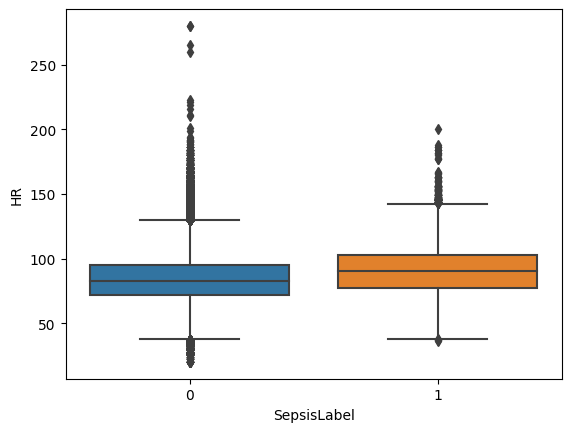

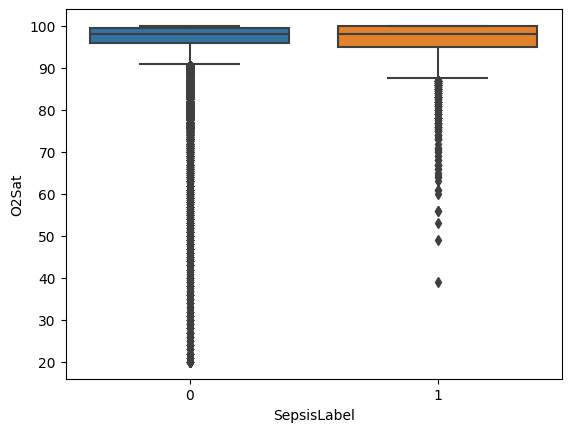

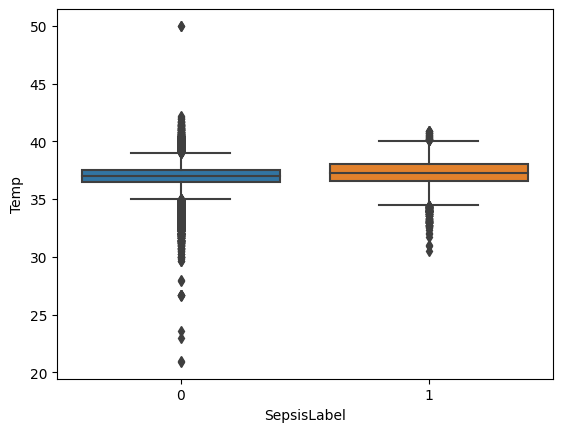

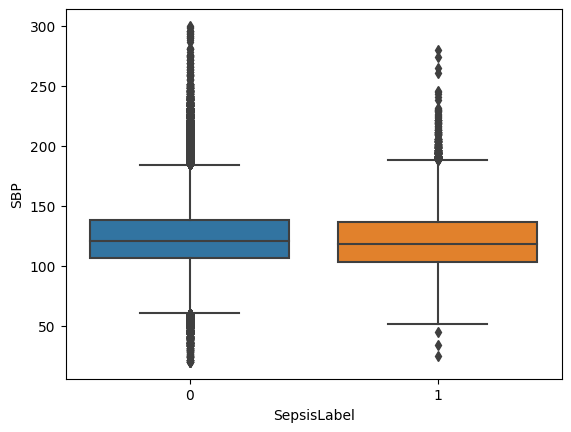

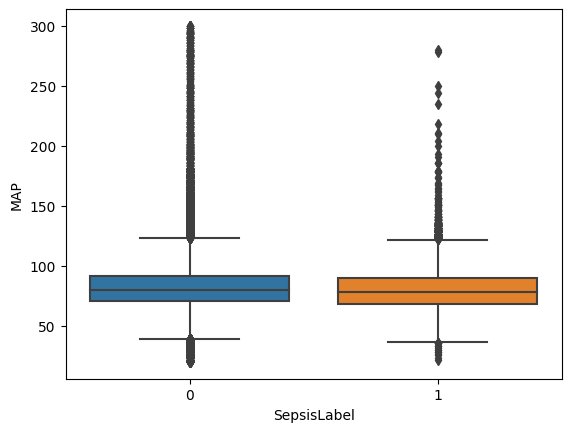

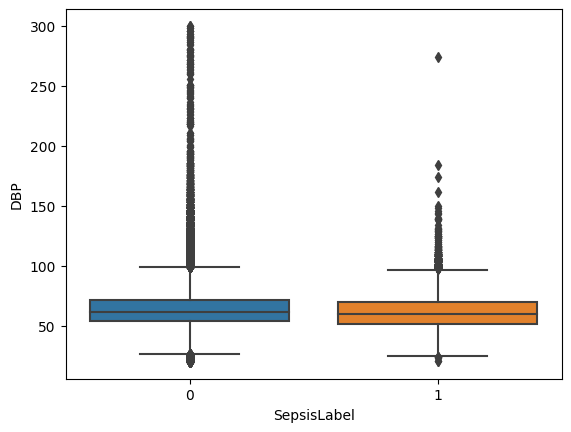

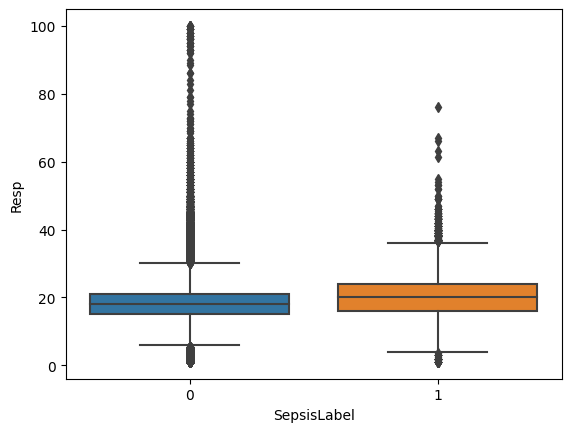

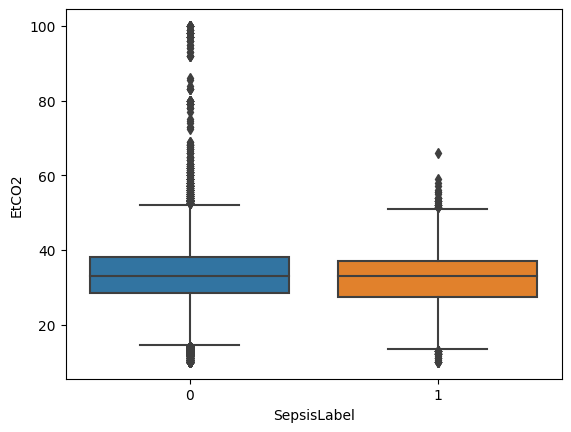

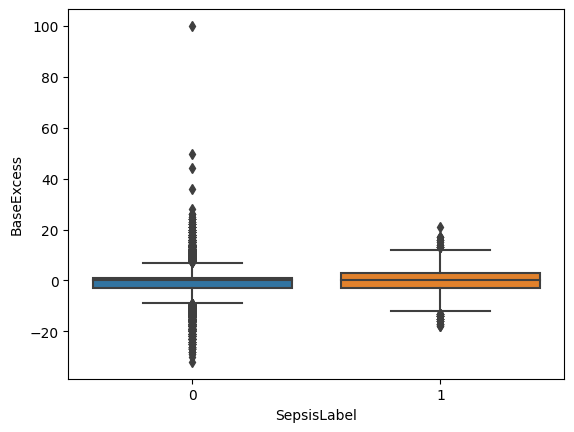

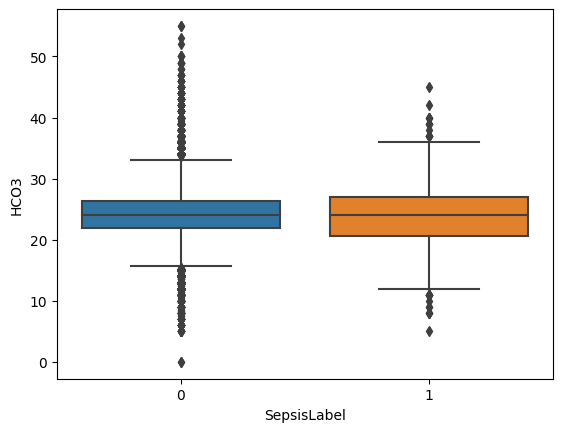

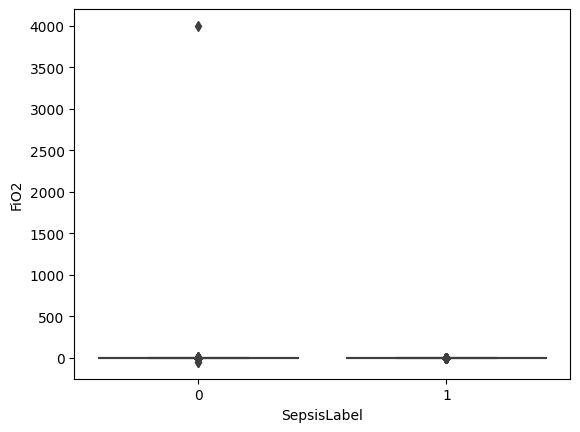

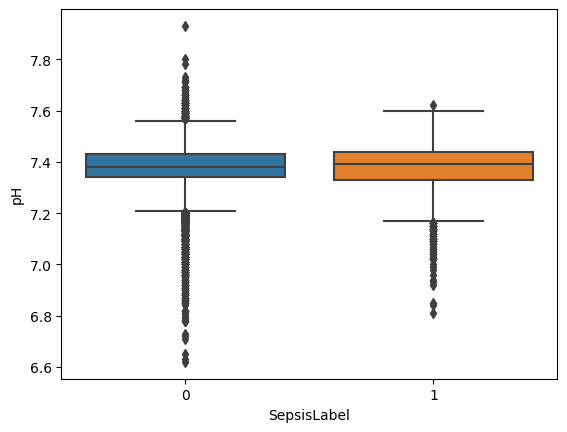

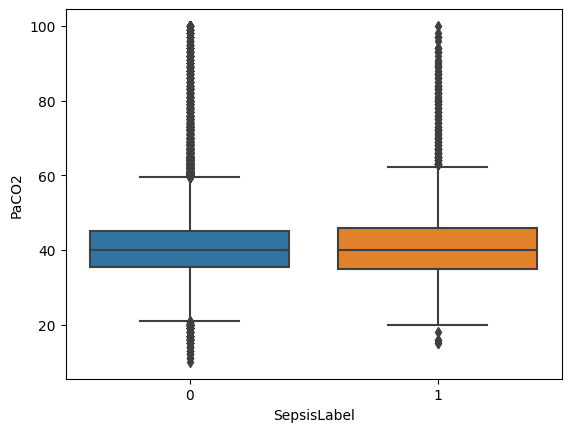

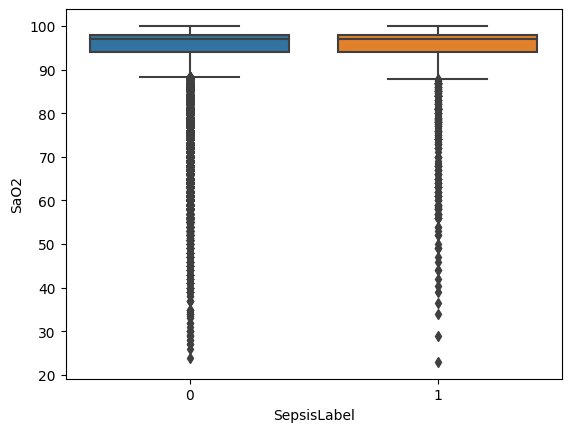

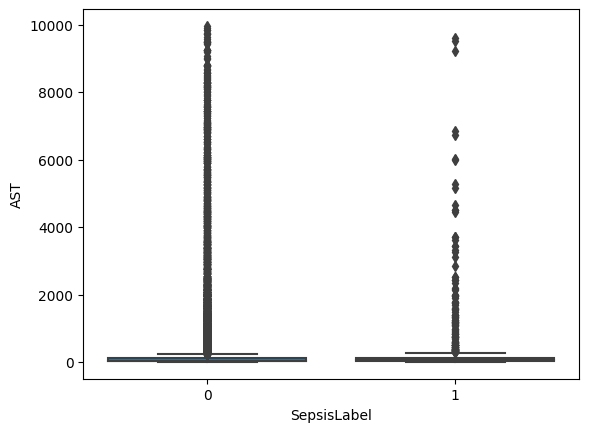

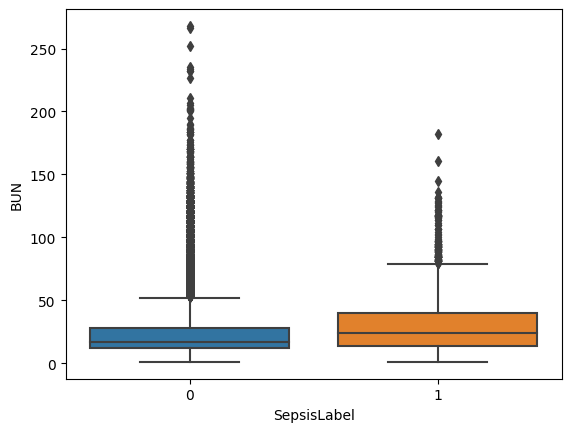

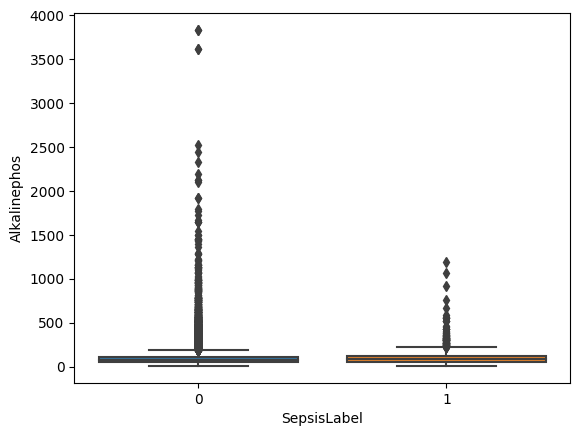

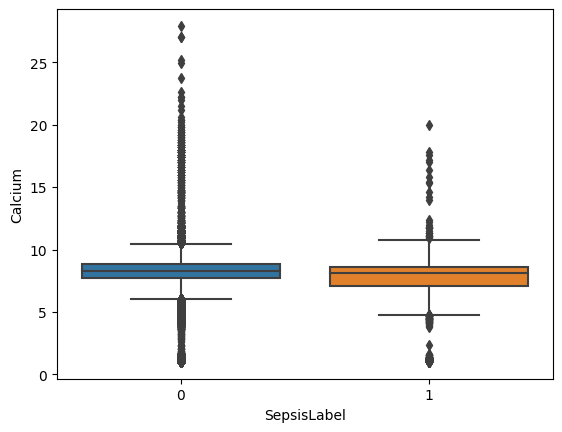

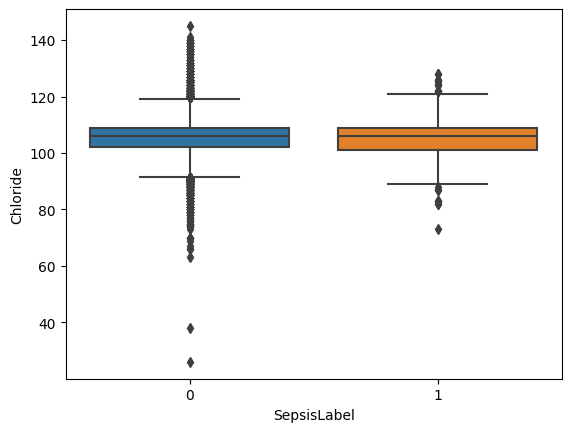

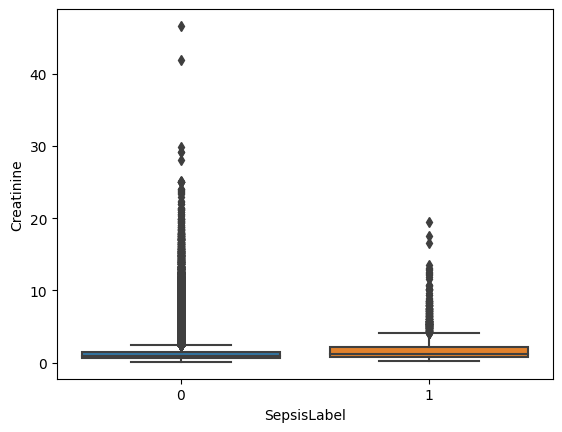

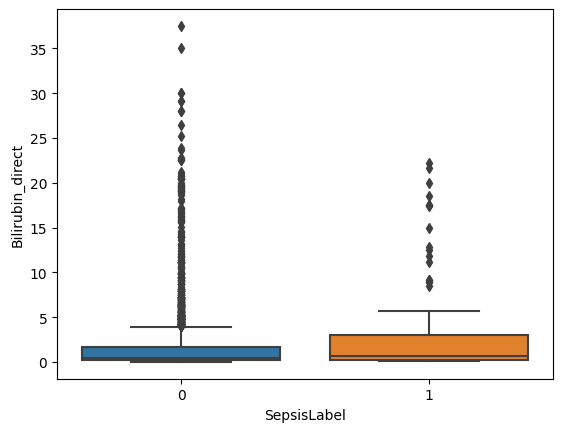

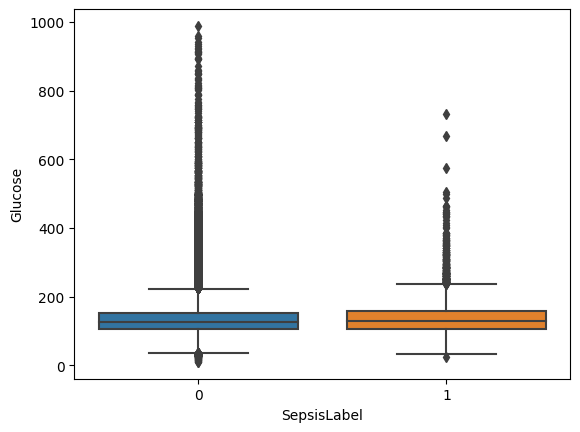

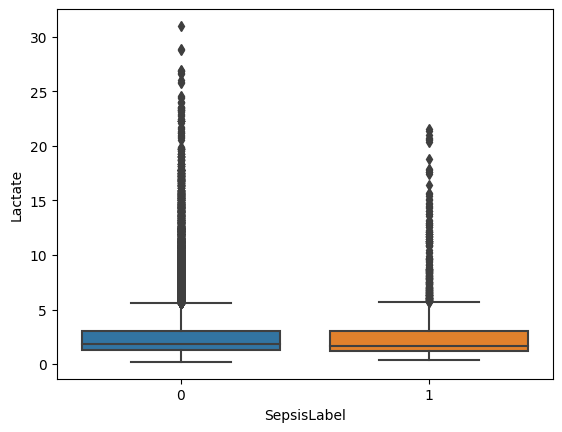

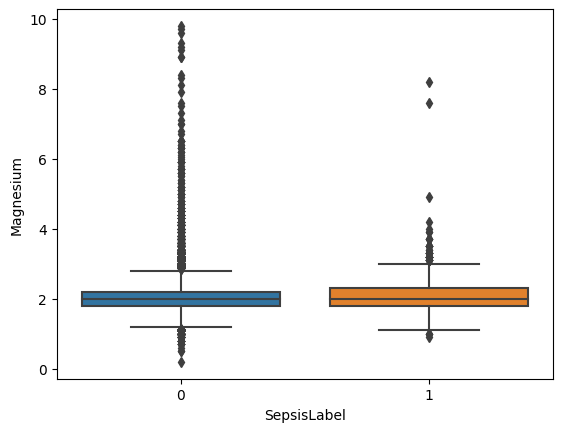

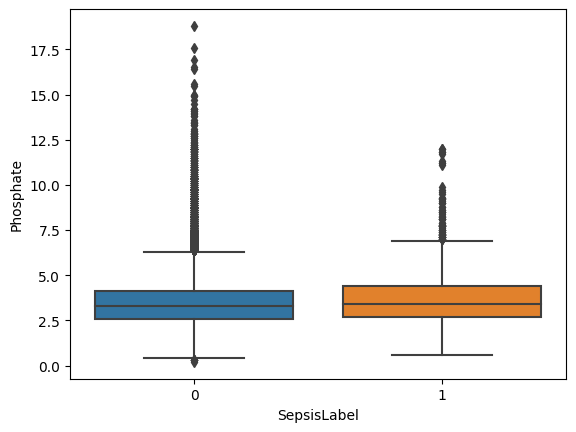

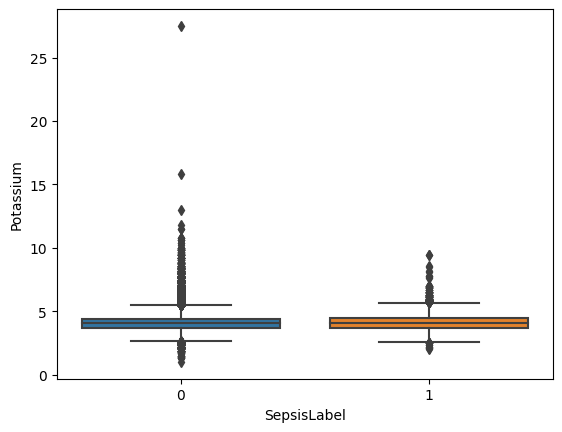

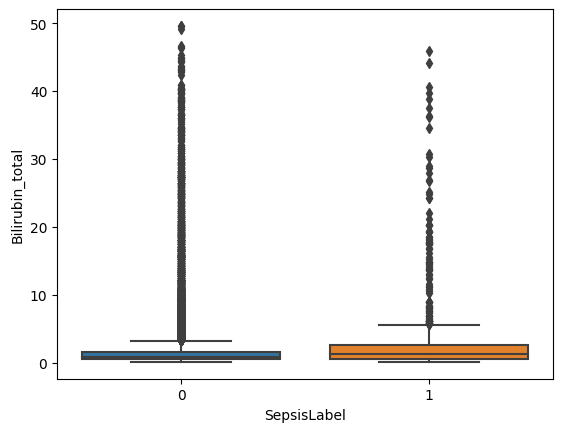

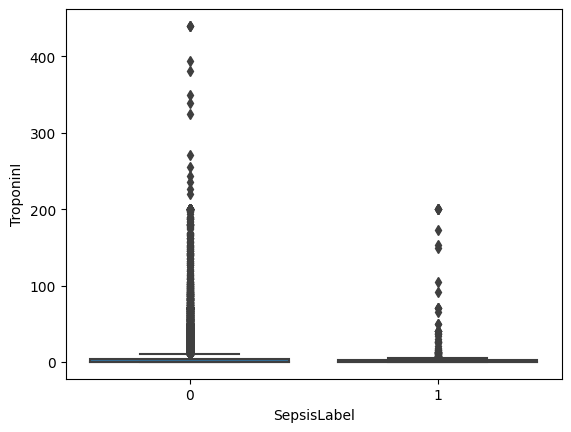

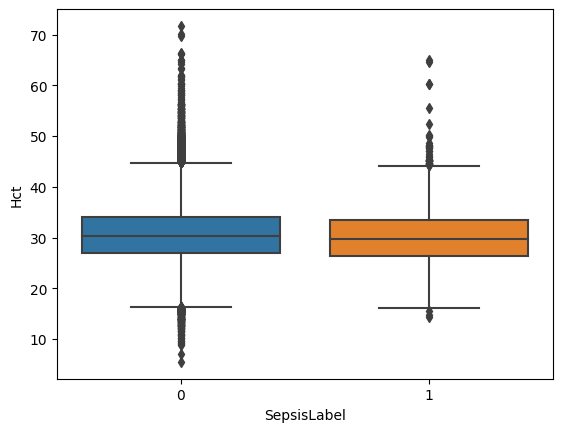

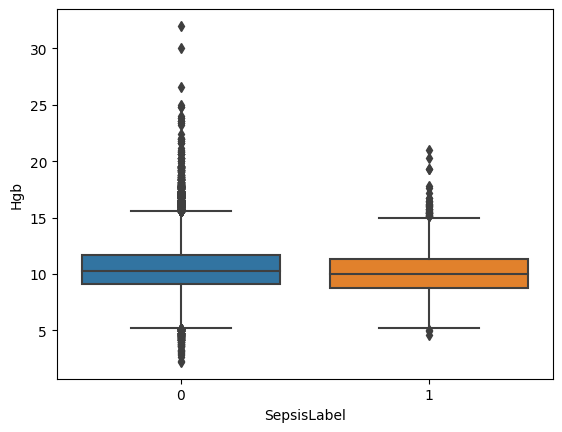

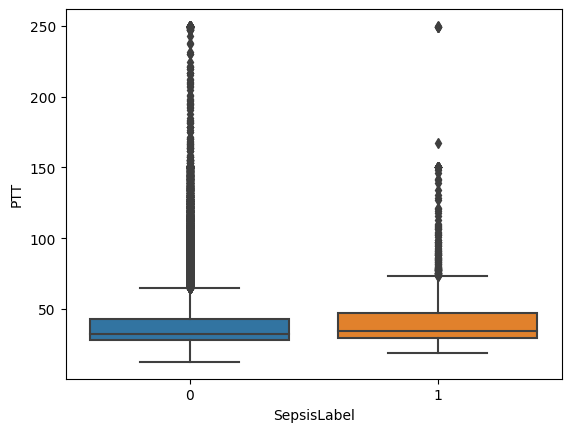

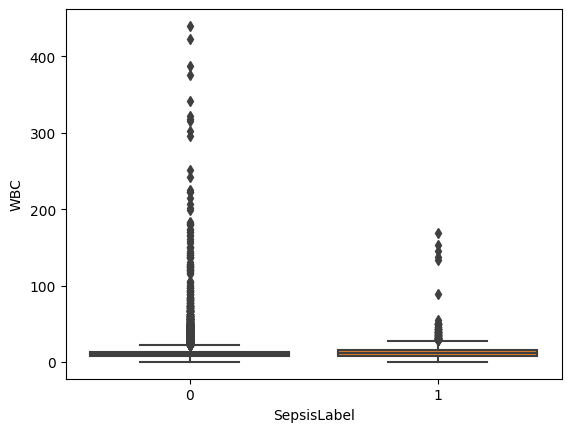

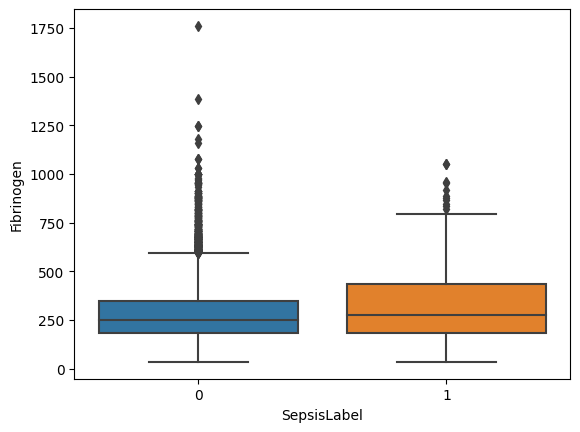

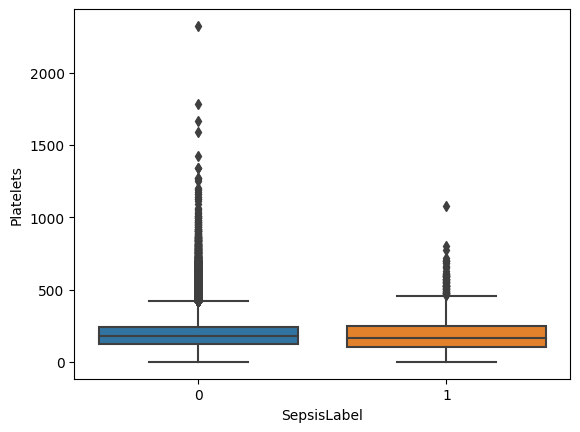

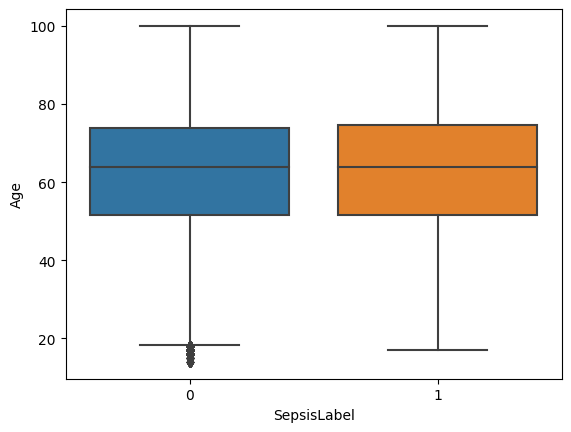

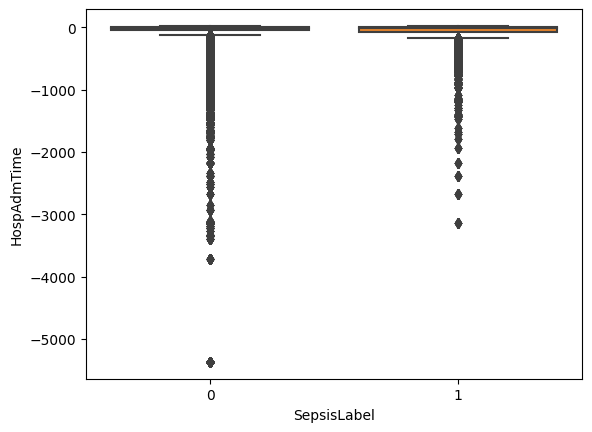

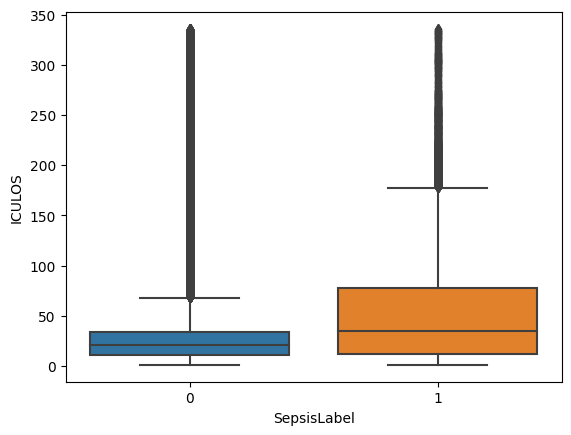

In [25]:
for i, var in enumerate(cont_vars):
  plt.figure(i)
  ax = sns.boxplot(x="SepsisLabel", y=var, data=filter_df)

### Base-stage missing handling

At this stage, only a small set of stable or background variables is lightly imputed, including Age, Gender, HospAdmTime, and ICULOS. Most dynamic clinical measurements are intentionally left missing at this stage so that missingness patterns can be preserved for downstream feature engineering and sequence preparation.

In [26]:
# Base-stage imputation for a small set of stable/background variables
X = filter_df.copy()
X = X.sort_values(['id', 'hour']).reset_index(drop=True)

if 'Age' in X.columns:
    X['Age'] = X['Age'].fillna(X['Age'].median())

if 'Gender' in X.columns:
    mode_gender = X['Gender'].mode(dropna=True)
    if len(mode_gender) > 0:
        X['Gender'] = X['Gender'].fillna(mode_gender.iloc[0])

if 'HospAdmTime' in X.columns:
    X['HospAdmTime'] = X.groupby('id')['HospAdmTime'].ffill().bfill()
    X['HospAdmTime'] = X['HospAdmTime'].fillna(X['HospAdmTime'].median())

if 'ICULOS' in X.columns:
    X['ICULOS'] = X.groupby('id')['ICULOS'].ffill().bfill()

print(X.shape)
print((X.isnull().sum() / len(X) * 100).sort_values(ascending=False).head(20))

(1552210, 41)
Bilirubin_direct    99.807371
Fibrinogen          99.340167
TroponinI           99.047745
Bilirubin_total     98.509158
Alkalinephos        98.393194
AST                 98.377604
Lactate             97.329872
PTT                 97.055875
SaO2                96.549372
EtCO2               96.286843
Phosphate           95.986303
HCO3                95.810618
Chloride            95.460279
BaseExcess          94.579020
PaCO2               94.440121
Calcium             94.116067
Platelets           94.059502
Creatinine          93.904433
Magnesium           93.689578
WBC                 93.593199
dtype: float64


### Remaining missing values are intentionally preserved

Many dynamic clinical variables still remain missing after base-stage cleaning. This is intentional, as the missingness pattern will be handled later during feature engineering and sequence preparation.

In [27]:
missing = (X.isnull().sum() / X.shape[0]) * 100
missing

id                   0.000000
hour                 0.000000
SepsisLabel          0.000000
HR                   9.882619
O2Sat               13.061119
Temp                66.162697
SBP                 14.576958
MAP                 12.451279
DBP                 31.345887
Resp                15.354559
EtCO2               96.286843
BaseExcess          94.579020
HCO3                95.810618
FiO2                91.665754
pH                  93.069688
PaCO2               94.440121
SaO2                96.549372
AST                 98.377604
BUN                 93.134434
Alkalinephos        98.393194
Calcium             94.116067
Chloride            95.460279
Creatinine          93.904433
Bilirubin_direct    99.807371
Glucose             82.894325
Lactate             97.329872
Magnesium           93.689578
Phosphate           95.986303
Potassium           90.689082
Bilirubin_total     98.509158
TroponinI           99.047745
Hct                 91.145979
Hgb                 92.617558
PTT       

### Save this processed data for later access

In [28]:
X.to_csv('stage1_base_clean.csv', index=False)

In [29]:
signals = ['HR', 'MAP', 'O2Sat', 'SBP', 'Resp', 'DBP', 'Temp', 'id', 'hour', 'SepsisLabel']

In [30]:
other_cols = [var for var in X.columns if var not in signals]

In [31]:
other_cols

['EtCO2',
 'BaseExcess',
 'HCO3',
 'FiO2',
 'pH',
 'PaCO2',
 'SaO2',
 'AST',
 'BUN',
 'Alkalinephos',
 'Calcium',
 'Chloride',
 'Creatinine',
 'Bilirubin_direct',
 'Glucose',
 'Lactate',
 'Magnesium',
 'Phosphate',
 'Potassium',
 'Bilirubin_total',
 'TroponinI',
 'Hct',
 'Hgb',
 'PTT',
 'WBC',
 'Fibrinogen',
 'Platelets',
 'Age',
 'Gender',
 'HospAdmTime',
 'ICULOS']

### Return some ID's of the patients that get sepsis

In [32]:
sepsis_id = X.loc[X['SepsisLabel'] == 1]['id'].unique()

In [33]:
# returns the first 10 patients with sepsis
sepsis_id[:20]

array([  8,  10,  14,  17,  21,  27,  33,  41,  52,  55,  57,  62,  63,
        77, 140, 160, 170, 177, 184, 187])

### Plot a sample Heart Rate between a sepsis and non-sepsis patient to see the difference in pattern over time

In [34]:
rcParams['figure.figsize'] = 10, 10

In [35]:
# # Function to map the colors as a list from the input list of x variables
colors = {1: 'red', 0: '#1f77b4'}

Text(0.5, 1.0, 'Heart Rate of A Non-Sepsis Patient Over Time')

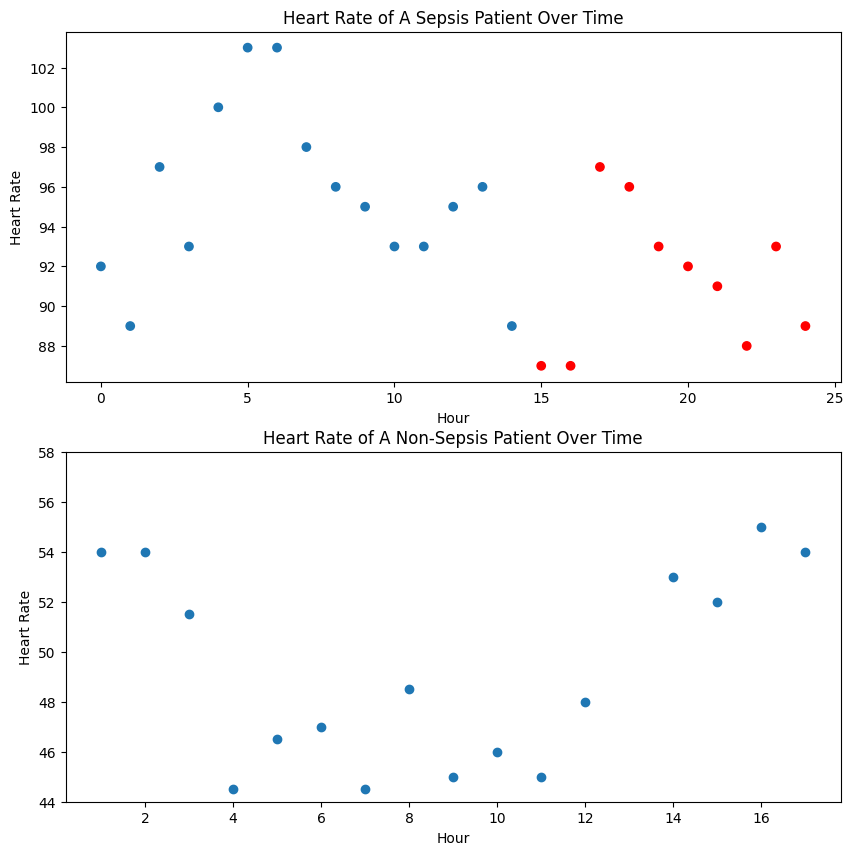

In [36]:
fig = plt.figure()
ax1 = fig.add_subplot(211)
ax2 = fig.add_subplot(212)

ax1.scatter(X[X['id']==52]['hour'].values, X[X['id']==52]['HR'], c = X[X['id']==52]['SepsisLabel'].apply(lambda x: colors[x]))
ax1.set_xlabel('Hour')
ax1.set_ylabel('Heart Rate')
ax1.set_title('Heart Rate of A Sepsis Patient Over Time')

ax2.scatter(X[X['id']==95]['hour'].values, X[X['id']==95]['HR'])
ax2.set_xlabel('Hour')
ax2.set_ylabel('Heart Rate')
ax2.set_ylim([44, 58])
ax2.set_title('Heart Rate of A Non-Sepsis Patient Over Time')

### Plot Mean Arterial Pressure (MAP) of the same sepsis and non-sepsis patient

In [37]:
rcParams['figure.figsize'] = 10, 10

In [38]:
# Map sepsis labels to plot colors.
colors = {1: 'red', 0: '#1f77b4'}

Text(0.5, 1.0, 'Mean Arterial Pressure of A Non-Sepsis Patient Over Time')

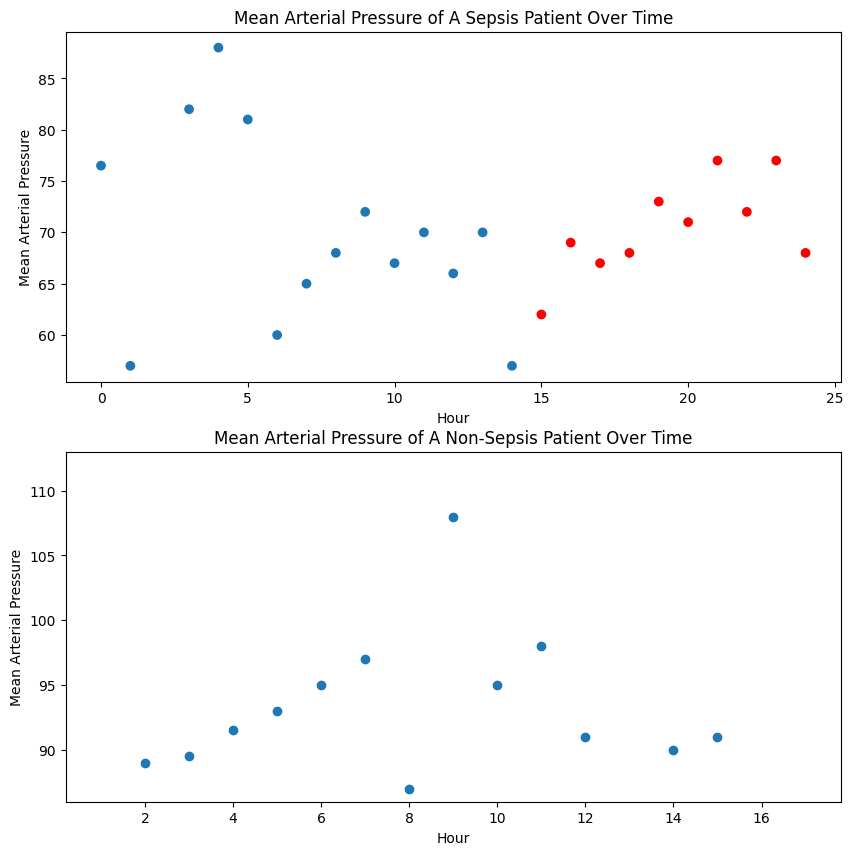

In [39]:
fig = plt.figure()
ax1 = fig.add_subplot(211)
ax2 = fig.add_subplot(212)

ax1.scatter(X[X['id']==52]['hour'].values, X[X['id']==52]['MAP'], c = X[X['id']==52]['SepsisLabel'].apply(lambda x: colors[x]))
ax1.set_xlabel('Hour')
ax1.set_ylabel('Mean Arterial Pressure')
ax1.set_title('Mean Arterial Pressure of A Sepsis Patient Over Time')


ax2.scatter(X[X['id']==95]['hour'].values, X[X['id']==95]['MAP'])
ax2.set_xlabel('Hour')
ax2.set_ylabel('Mean Arterial Pressure')
ax2.set_ylim([86, 113])
ax2.set_title('Mean Arterial Pressure of A Non-Sepsis Patient Over Time')